Problem Statement Build an LSTM for Text Classification — Reuse the same tokenize + pad_sequences(maxlen=50) approach as Day 10. Build this exact model: Embedding(5000, 32) → LSTM(32) → Dense(1, activation="sigmoid") (or Dense(n_classes, "softmax") for more than 2 classes) — this is the Day 10 architecture with SimpleRNN swapped for LSTM, nothing else changes. Train for 5 epochs and report test accuracy. If time remains, copy the notebook and swap LSTM for GRU to see whether the result changes — this is a bonus, not required. In 1–2 sentences, explain what the forget gate lets an LSTM do that a plain RNN cannot. https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

Load and inspect the dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Reviews.csv")

# First 5 rows
display(df.head())

# Shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types and missing values
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe(include="all"))

# Score distribution
print("\nScore Counts:")
print(df["Score"].value_counts().sort_index())

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Dataset Shape: (568454, 10)

Columns:
Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
count,568454.000000,568454,568454,568428,568454.000000,568454.00000,568454.000000,5.684540e+05,568427,568454
unique,NaN,74258,256059,218415,NaN,NaN,NaN,NaN,295742,393579
top,NaN,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",NaN,NaN,NaN,NaN,Delicious!,"This review will make me sound really stupid, ..."
freq,NaN,913,448,451,NaN,NaN,NaN,NaN,2462,199
mean,284227.500000,NaN,NaN,NaN,1.743817,2.22881,4.183199,1.296257e+09,NaN,NaN
std,164098.679298,NaN,NaN,NaN,7.636513,8.28974,1.310436,4.804331e+07,NaN,NaN
min,1.000000,NaN,NaN,NaN,0.000000,0.00000,1.000000,9.393408e+08,NaN,NaN
25%,142114.250000,NaN,NaN,NaN,0.000000,0.00000,4.000000,1.271290e+09,NaN,NaN
50%,284227.500000,NaN,NaN,NaN,0.000000,1.00000,5.000000,1.311120e+09,NaN,NaN
75%,426340.750000,NaN,NaN,NaN,2.000000,2.00000,5.000000,1.332720e+09,NaN,NaN



Score Counts:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


Missing values

In [22]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [23]:
# Remove rows where review text is missing
df = df.dropna(subset=["Text"])

print("\nMissing values after cleaning Text:")
print(df["Text"].isnull().sum())


Missing values after cleaning Text:
0


Check duplicates

In [24]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [25]:
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


Check outliers

In [26]:
numeric_cols = [
    "Score",
    "HelpfulnessNumerator",
    "HelpfulnessDenominator"
]

display(df[numeric_cols].describe())

,Score,HelpfulnessNumerator,HelpfulnessDenominator
count,568454.000000,568454.000000,568454.00000
mean,4.183199,1.743817,2.22881
std,1.310436,7.636513,8.28974
min,1.000000,0.000000,0.00000
25%,4.000000,0.000000,0.00000
50%,5.000000,0.000000,1.00000
75%,5.000000,2.000000,2.00000
max,5.000000,866.000000,923.00000


In [27]:
print("Minimum Score:", df["Score"].min())
print("Maximum Score:", df["Score"].max())

Minimum Score: 1
Maximum Score: 5


Feature Engineering

In [28]:
df["review_length"] = df["Text"].str.len()

df[["Text", "review_length"]].head()

,Text,review_length
0,I have bought several of the Vitality canned d...,263
1,Product arrived labeled as Jumbo Salted Peanut...,190
2,This is a confection that has been around a fe...,509
3,If you are looking for the secret ingredient i...,219
4,Great taffy at a great price. There was a wid...,140


In [29]:
df["word_count"] = df["Text"].str.split().str.len()

df[["Text", "word_count"]].head()

,Text,word_count
0,I have bought several of the Vitality canned d...,48
1,Product arrived labeled as Jumbo Salted Peanut...,31
2,This is a confection that has been around a fe...,94
3,If you are looking for the secret ingredient i...,41
4,Great taffy at a great price. There was a wid...,27


In [30]:
df["helpfulness_ratio"] = np.where(
    df["HelpfulnessDenominator"] > 0,
    df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"],
    0
)

df[[
    "HelpfulnessNumerator",
    "HelpfulnessDenominator",
    "helpfulness_ratio"
]].head()

,HelpfulnessNumerator,HelpfulnessDenominator,helpfulness_ratio
0,1,1,1.0
1,0,0,0.0
2,1,1,1.0
3,3,3,1.0
4,0,0,0.0


sentiment target

In [31]:
# Remove neutral reviews
df = df[df["Score"] != 3].copy()

# 4-5 = Positive (1)
# 1-2 = Negative (0)

df["label"] = (df["Score"] > 3).astype(int)

print(df["label"].value_counts())

print("\nPercentages:")
print(df["label"].value_counts(normalize=True) * 100)

label
1    443777
0     82037
Name: count, dtype: int64

Percentages:
label
1    84.398095
0    15.601905
Name: proportion, dtype: float64


EDA Chart

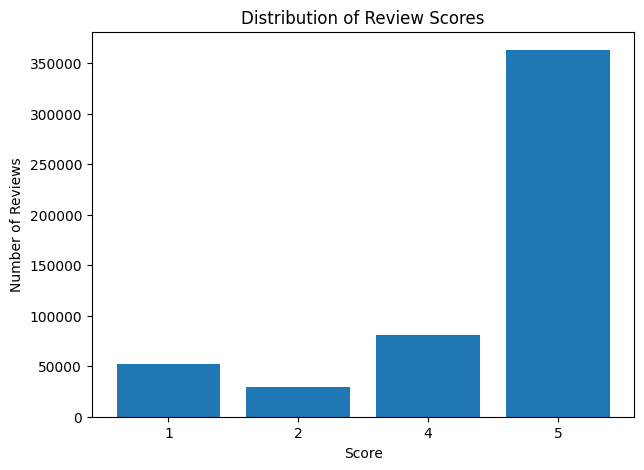

In [32]:
score_counts = df["Score"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(score_counts.index.astype(str), score_counts.values)

plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")

plt.show()

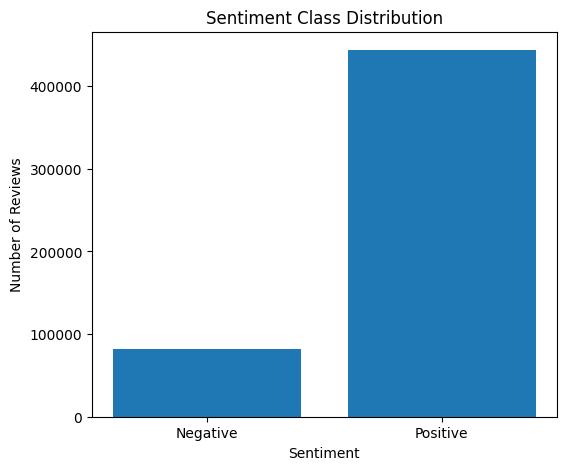

In [33]:
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 5))

plt.bar(
    ["Negative", "Positive"],
    [label_counts.get(0, 0), label_counts.get(1, 0)]
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

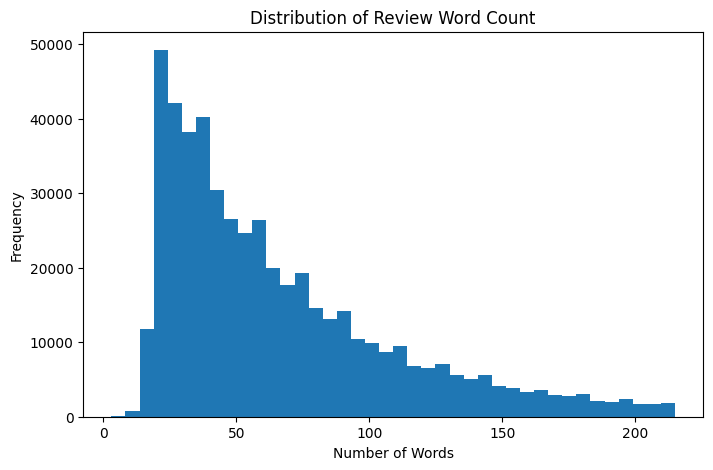

In [34]:
limit = df["word_count"].quantile(0.95)

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["word_count"] <= limit, "word_count"],
    bins=40
)

plt.title("Distribution of Review Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_812/3225845011.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


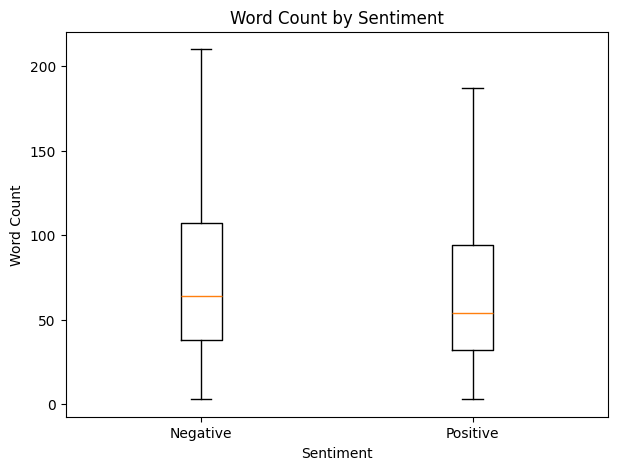

In [35]:
negative = df.loc[df["label"] == 0, "word_count"]
positive = df.loc[df["label"] == 1, "word_count"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [negative, positive],
    labels=["Negative", "Positive"],
    showfliers=False
)

plt.title("Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")

plt.show()

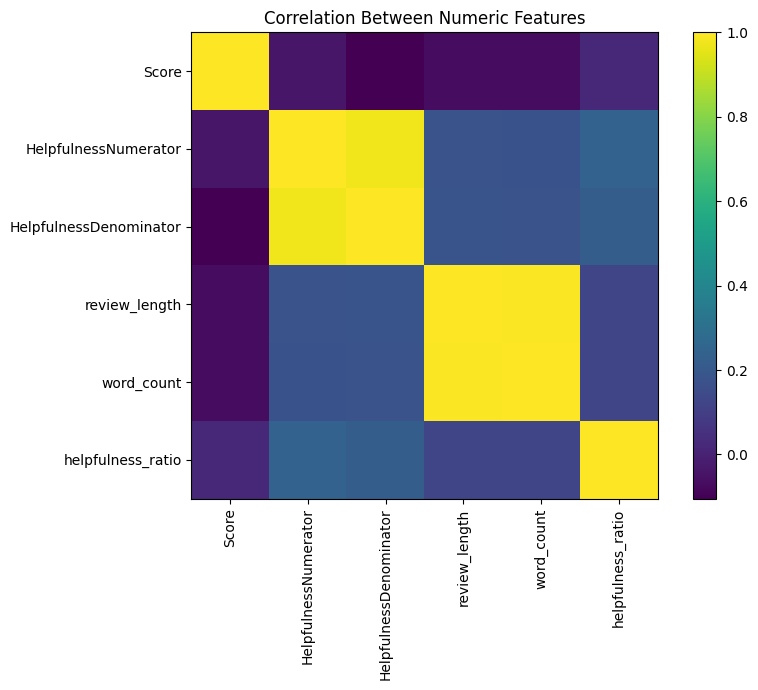

In [36]:
corr_columns = [
    "Score",
    "HelpfulnessNumerator",
    "HelpfulnessDenominator",
    "review_length",
    "word_count",
    "helpfulness_ratio"
]

corr = df[corr_columns].corr()

plt.figure(figsize=(9, 7))

plt.imshow(corr)
plt.colorbar()

plt.xticks(
    range(len(corr_columns)),
    corr_columns,
    rotation=90
)

plt.yticks(
    range(len(corr_columns)),
    corr_columns
)

plt.title("Correlation Between Numeric Features")

plt.tight_layout()
plt.show()

Five data-grounded insights

In [37]:
print("Total rows after cleaning:", len(df))

print("\nSentiment counts:")
print(df["label"].value_counts())

print("\nSentiment percentages:")
print(df["label"].value_counts(normalize=True) * 100)

print("\nAverage word count by sentiment:")
print(df.groupby("label")["word_count"].mean())

print("\nAverage review length by sentiment:")
print(df.groupby("label")["review_length"].mean())

print("\nAverage helpfulness ratio by sentiment:")
print(df.groupby("label")["helpfulness_ratio"].mean())

print("\nMedian word count:")
print(df["word_count"].median())

Total rows after cleaning: 525814

Sentiment counts:
label
1    443777
0     82037
Name: count, dtype: int64

Sentiment percentages:
label
1    84.398095
0    15.601905
Name: proportion, dtype: float64

Average word count by sentiment:
label
0    88.309690
1    77.298751
Name: word_count, dtype: float64

Average review length by sentiment:
label
0    482.644636
1    419.559896
Name: review_length, dtype: float64

Average helpfulness ratio by sentiment:
label
0    0.395239
1    0.415249
Name: helpfulness_ratio, dtype: float64

Median word count:
55.0


LSTM preprocessing

In [38]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df["Text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 420651
Testing reviews: 105163


In [39]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Padding:

In [40]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=50
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=50
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (420651, 50)
Testing shape: (105163, 50)


LSTM

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(5000, 32),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
10517/10517 ━━━━━━━━━━━━━━━━━━━━ 291s 27ms/step - accuracy: 0.9220 - loss: 0.1973 - val_accuracy: 0.9379 - val_loss: 0.1593
Epoch 2/5
10517/10517 ━━━━━━━━━━━━━━━━━━━━ 290s 28ms/step - accuracy: 0.9467 - loss: 0.1397 - val_accuracy: 0.9476 - val_loss: 0.1378
Epoch 3/5
10517/10517 ━━━━━━━━━━━━━━━━━━━━ 335s 29ms/step - accuracy: 0.9567 - loss: 0.1162 - val_accuracy: 0.9513 - val_loss: 0.1314
Epoch 4/5
10517/10517 ━━━━━━━━━━━━━━━━━━━━ 316s 28ms/step - accuracy: 0.9636 - loss: 0.0992 - val_accuracy: 0.9513 - val_loss: 0.1300
Epoch 5/5
10517/10517 ━━━━━━━━━━━━━━━━━━━━ 309s 27ms/step - accuracy: 0.9693 - loss: 0.0852 - val_accuracy: 0.9539 - val_loss: 0.1365


Test accuracy

In [43]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

3287/3287 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - accuracy: 0.9528 - loss: 0.1411
Test Loss: 0.1411159187555313
Test Accuracy: 0.9527971148490906
Test Accuracy: 95.28%


## LSTM Forget Gate

The forget gate allows an LSTM to decide which old information should be
forgotten and which important information should be kept. This helps an LSTM
remember useful information for longer than a plain RNN.